In [1]:
import os
import time
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as Tr
import torchvision.transforms.functional as TF


from glob import glob
from PIL import Image
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
import imageio.v2 as imageio

In [2]:
# === Download checkpoint ===
checkpoint_path = "./checkpoints/track_on_checkpoint.pt"

# !wget -O ./checkpoints/track_on_checkpoint.pt "https://huggingface.co/gaydemir/track_on/resolve/main/track_on_checkpoint.pt"

In [3]:
# === Helper functions ===
def read_video(video_path):
    reader = imageio.get_reader(video_path)
    frames = []
    for i, im in enumerate(reader):
        frames.append(np.array(im))
    video = np.stack(frames)
    video = torch.from_numpy(video).permute(0, 3, 1, 2).float()  # (T, 3, 720, 1920)
    
    print(f"{video.shape[0]} frames in video")
    
    plt.imshow(video[0].permute(1, 2, 0).long())
    
    return video
    
def write_gif(png_dir, out_dir):
    images = []
    
    sorted_files = sorted([f for f in os.listdir(png_dir) if f.endswith('.png')], key=lambda x: int(x.split('.')[0]))
    
    for z, file_name in enumerate(sorted_files):    
        file_path = os.path.join(png_dir, file_name)
        images.append(imageio.imread(file_path))

    imageio.mimsave(out_dir, images, fps=30)

58 frames in video


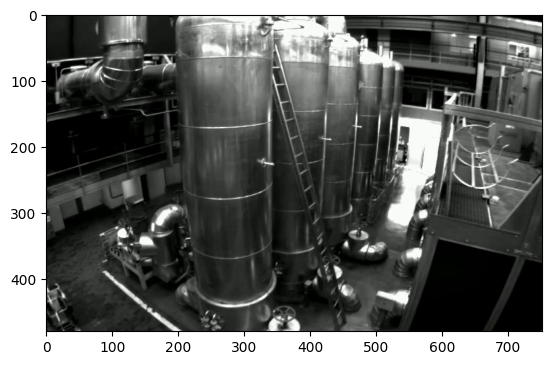

In [4]:
# === Read video ====
video_path = "../MH_01_1.mp4"
video = read_video(video_path)  # (T, 3, H, W)
video = video[:20]  # Use only first 20 frames
# === === ===

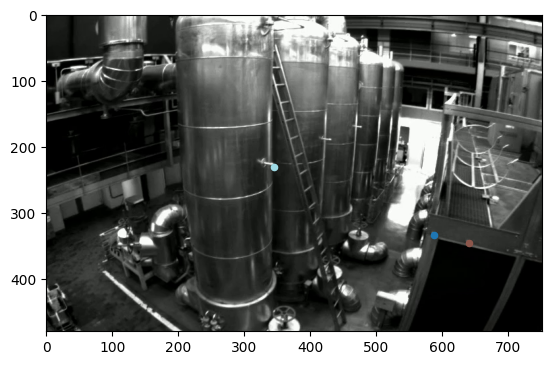

In [12]:
def get_updated_queries(t):
    if t < 11:
        return torch.tensor([[0, 587, 333], [0, 640, 345], [0, 345, 230]]), []
    elif t == 11:
        return torch.tensor([[0, 587, 333], [0, 640, 345], [10, 396, 208]]), [2]  # 396, 208
    else:
        return torch.tensor([[0, 587, 333], [0, 640, 345], [10, 396, 208]]), []
    
queries, _ = get_updated_queries(0)
N = queries.shape[1]
distinct_colors = plt.cm.tab20(np.linspace(0, 1, N))
hex_colors = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in distinct_colors]
plt.imshow(video[0].permute(1, 2, 0).long())
for i, q in enumerate(queries):
    plt.scatter(q[1], q[2], s=20, c=hex_colors[i])

In [13]:
# === Set Model Arguments ===
from utils.train_utils import restart_from_checkpoint_not_dist

class Args:
    def __init__(self):
        self.input_size = [384, 512]

        self.N = 384
        self.T = 18
        self.stride = 4
        self.transformer_embedding_dim = 256
        self.cnn_corr = False
        self.linear_visibility = False
        
        self.num_layers = 3
        self.num_layers_offset_head = 3
        
        self.num_layers_rerank = 3
        self.num_layers_rerank_fusion = 1
        self.top_k_regions = 16

        self.num_layers_spatial_writer = 3
        self.num_layers_spatial_self = 1
        self.num_layers_spatial_cross = 1
        
        self.memory_size = 12
        self.val_memory_size = 96
        self.val_vis_delta = 0.9
        self.random_memory_mask_drop = 0

        self.lambda_point = 5.0
        self.lambda_vis = 1.0
        self.lambda_offset = 1.0
        self.lambda_uncertainty = 1.0
        self.lambda_top_k = 1.0
        
        self.epoch_num = 4
        self.lr = 1e-3
        self.wd = 1e-4
        self.bs = 1
        self.gradient_acc_steps = 1

        self.validation = False
        self.checkpoint_path = checkpoint_path
        self.seed = 1234
        self.loss_after_query = True

        self.gpus = torch.cuda.device_count()

args = Args()

# Option 1: Frame inputs

In [ ]:
from trackon.track_on_ff import TrackOnFF    # Frame Inputs

model = TrackOnFF(args)
restart_from_checkpoint_not_dist(args, run_variables={}, model=model)

model.cuda().eval()
model.set_memory_size(args.val_memory_size, args.val_memory_size)
model.visibility_treshold = args.val_vis_delta


=> loaded 'model' from checkpoint with msg <All keys matched successfully>


In [15]:
T = video.shape[0]

png_folder = "./out/MH_01_1_updated"
Path(png_folder).mkdir(parents=True, exist_ok=True)

vis_all = []
point_all = []

with torch.no_grad():
    for t in range(T):
    
        # === For the first frame, initialize the queries and memories ===
        if t == 0:
            queries, _ = get_updated_queries(t)
            model.init_queries_and_memory(queries.cuda(), video[t].unsqueeze(0).cuda())
        else:
            queries, removed_indices = get_updated_queries(t)
            model.update_queries_and_memory(queries.cuda(), video[t].unsqueeze(0).cuda(), removed_indices)
        N = queries.shape[0]
        # === === ===
    
        # === Model forward, for each frame ===
        
        point, vis = model.ff_forward(video[t].unsqueeze(0).cuda())
        # === === ===
    
        # === Save the predictions frame-by-frame ===
        vis_all.append(vis)
        point_all.append(point)
        
        plt.imshow(video[t].permute(1, 2, 0).long())
        for n in range(N):
            if vis[n]:
                plt.scatter(point[n, 0].cpu(), point[n, 1].cpu(), c=hex_colors[n], s=20)
    
        plt.axis("off")
        plt.savefig(os.path.join(png_folder, f"{t}.png"), bbox_inches='tight')
        plt.clf()
        # === === ===

write_gif(png_folder, os.path.join(png_folder, "out.gif"))

t:  0
q_init:  torch.Size([1, 3, 256])
t:  1
q_init:  torch.Size([1, 3, 256])
t:  2
q_init:  torch.Size([1, 3, 256])
t:  3
q_init:  torch.Size([1, 3, 256])
t:  4
q_init:  torch.Size([1, 3, 256])
t:  5
q_init:  torch.Size([1, 3, 256])
t:  6
q_init:  torch.Size([1, 3, 256])
t:  7
q_init:  torch.Size([1, 3, 256])
t:  8
q_init:  torch.Size([1, 3, 256])
t:  9
q_init:  torch.Size([1, 3, 256])
t:  10
q_init:  torch.Size([1, 3, 256])
q_init_t:  torch.Size([1, 3, 256])
context memory:  torch.Size([1, 3, 96, 256])
past mask:  torch.Size([1, 3, 96])
queried_now_or_before:  tensor([[True, True, True]], device='cuda:0')
t:  11
N_new:  1
N:  3
q_init shape:  torch.Size([1, 3, 256])
t:  11
q_init:  torch.Size([1, 3, 256])
q_init_t:  torch.Size([1, 3, 256])
context memory:  torch.Size([1, 3, 96, 256])
past mask:  torch.Size([1, 3, 96])
queried_now_or_before:  tensor([[True, True, True]], device='cuda:0')
t:  12
q_init:  torch.Size([1, 3, 256])
q_init_t:  torch.Size([1, 3, 256])
context memory:  torch.

<Figure size 640x480 with 0 Axes>